## Exercise 3

### a)
For a constant volume reactor, the general mass balance (molar balance) for any species $i$, which is $\frac{1}{V} \frac{dn_i}{dt}$, simplifies directly to the rate of change of its concentration, $\frac{d[C_i]}{dt}$. 

Based on the reversible Michaelis-Menten reaction scheme:
$E + S \rightleftharpoons ES \rightleftharpoons E + P$

We can break this down into four elementary reaction steps:
Forward step 1: $E + S \xrightarrow{k_{1,f}} ES$
Reverse step 1: $ES \xrightarrow{k_{1,b}} E + S$
Forward step 2: $ES \xrightarrow{k_{2,f}} E + P$
Reverse step 2: $E + P \xrightarrow{k_{2,b}} ES$

Using the law of mass action, we can write the concentration balances (differential equations) for each of the four species in the system ($[E]$, $[S]$, $[ES]$, and $[P]$):
1. Enzyme $[E]$ Balance:The free enzyme is consumed in the first forward step and the second reverse step, and it is produced in the first reverse step and the second forward step.$$\frac{d[E]}{dt} = -k_{1,f}[E][S] + k_{1,b}[ES] + k_{2,f}[ES] - k_{2,b}[E][P]$$2. Substrate $[S]$ Balance:The substrate is consumed in the first forward step and produced in the first reverse step.$$\frac{d[S]}{dt} = -k_{1,f}[E][S] + k_{1,b}[ES]$$3. Enzyme-Substrate Complex $[ES]$ Balance:The complex is formed in the first forward step and the second reverse step, and it breaks down in the first reverse step and the second forward step.$$\frac{d[ES]}{dt} = k_{1,f}[E][S] - k_{1,b}[ES] - k_{2,f}[ES] + k_{2,b}[E][P]$$4. Product $[P]$ Balance:The product is formed in the second forward step and consumed in the second reverse step.$$\frac{d[P]}{dt} = k_{2,f}[ES] - k_{2,b}[E][P]$$

## Part b) Quasi Steady State Assumption (QSSA)

The QSSA assumes that the concentration of the intermediate complex $[ES]$ is time-invariant, meaning $\frac{d[ES]}{dt} = 0$.
We also apply the enzyme mass balance: $[E_0] = [E] + [ES]$, which rearranges to $[E] = [E_0] - [ES]$.

**Step 1: Find the expression for $[ES]$**
Substitute $[E]$ into the $\frac{d[ES]}{dt}$ equation and set it to $0$:
$$0 = k_{1,f}([E_0] - [ES])[S] - (k_{1,b} + k_{2,f})[ES] + k_{2,b}([E_0] - [ES])[P]$$

Expand the terms:
$$0 = k_{1,f}[E_0][S] - k_{1,f}[ES][S] - (k_{1,b} + k_{2,f})[ES] + k_{2,b}[E_0][P] - k_{2,b}[ES][P]$$

Group all $[ES]$ terms on one side:
$$[ES](k_{1,f}[S] + k_{1,b} + k_{2,f} + k_{2,b}[P]) = [E_0](k_{1,f}[S] + k_{2,b}[P])$$

Solve for $[ES]$:
$$[ES] = \frac{[E_0](k_{1,f}[S] + k_{2,b}[P])}{k_{1,b} + k_{2,f} + k_{1,f}[S] + k_{2,b}[P]}$$

**Step 2: Write the equation for $v = \frac{d[P]}{dt}$**
Substitute $[E]$ and $[ES]$ into the product formation equation:
$$v = \frac{d[P]}{dt} = k_{2,f}[ES] - k_{2,b}([E_0] - [ES])[P]$$
$$v = (k_{2,f} + k_{2,b}[P])[ES] - k_{2,b}[E_0][P]$$

Substitute the $[ES]$ expression into this equation:
$$v = (k_{2,f} + k_{2,b}[P]) \left( \frac{[E_0](k_{1,f}[S] + k_{2,b}[P])}{k_{1,b} + k_{2,f} + k_{1,f}[S] + k_{2,b}[P]} \right) - k_{2,b}[E_0][P]$$

To simplify, find a common denominator and expand the numerator (this algebra can get messy, so let's use Python in the next cell to do the heavy lifting and prove the final simplified form).

In [1]:
# --- Symbolic Verification of the QSSA Algebra for Part B ---
import sympy as sp
from IPython.display import display, Math

# Define variables
S, P, E0, ES = sp.symbols('S P E_0 ES', real=True, positive=True)
k1f, k1b, k2f, k2b = sp.symbols('k_{1f} k_{1b} k_{2f} k_{2b}', real=True, positive=True)

# 1. Define the expression for [ES] we derived
ES_expr = (E0 * (k1f*S + k2b*P)) / (k1b + k2f + k1f*S + k2b*P)

# 2. Define the rate equation v = dP/dt
v_unsimplified = (k2f + k2b*P)*ES_expr - k2b*E0*P

# 3. Simplify the rate equation
v_simplified = sp.simplify(v_unsimplified)

print("Simplified equation for the reaction rate v = d[P]/dt:")
display(Math(r'v = ' + sp.latex(v_simplified)))

Simplified equation for the reaction rate v = d[P]/dt:


<IPython.core.display.Math object>

The final simplified equation for the reaction rate is:
$$v = \frac{[E_0](k_{1,f} k_{2,f}[S] - k_{1,b} k_{2,b}[P])}{k_{1,b} + k_{2,f} + k_{1,f}[S] + k_{2,b}[P]}$$

## Part c) Deriving the Typical Form and Parameter Identification

To match the typical form provided, we must divide both the numerator and the denominator of our derived rate equation by the constant term in the denominator, which is $(k_{1,b} + k_{2,f})$.

$$v = \frac{ \frac{k_{1,f}k_{2,f}[E_0]}{k_{1,b} + k_{2,f}}[S] - \frac{k_{1,b}k_{2,b}[E_0]}{k_{1,b} + k_{2,f}}[P] }{ 1 + \frac{k_{1,f}}{k_{1,b} + k_{2,f}}[S] + \frac{k_{2,b}}{k_{1,b} + k_{2,f}}[P] }$$

Now we compare this to the given typical form:
$$v([S], [P]) = \frac{ \frac{V_{max,f}[S]}{K_{m,S}} - \frac{V_{max,b}[P]}{K_{m,P}} }{ 1 + \frac{[S]}{K_{m,S}} + \frac{[P]}{K_{m,P}} }$$

By mapping the terms, we can define the standard Michaelis-Menten parameters as functions of the elementary rate constants:

**1. Michaelis Constants ($K_m$):**
Look at the denominator terms for $[S]$ and $[P]$:
* $\frac{1}{K_{m,S}} = \frac{k_{1,f}}{k_{1,b} + k_{2,f}} \implies \mathbf{K_{m,S} = \frac{k_{1,b} + k_{2,f}}{k_{1,f}}}$
* $\frac{1}{K_{m,P}} = \frac{k_{2,b}}{k_{1,b} + k_{2,f}} \implies \mathbf{K_{m,P} = \frac{k_{1,b} + k_{2,f}}{k_{2,b}}}$

**2. Maximum Velocities ($V_{max}$):**
Look at the numerator terms:
* $\frac{V_{max,f}}{K_{m,S}} = \frac{k_{1,f}k_{2,f}[E_0]}{k_{1,b} + k_{2,f}}$
    Substituting $K_{m,S}$, we get: $\mathbf{V_{max,f} = k_{2,f}[E_0]}$
* $\frac{V_{max,b}}{K_{m,P}} = \frac{k_{1,b}k_{2,b}[E_0]}{k_{1,b} + k_{2,f}}$
    Substituting $K_{m,P}$, we get: $\mathbf{V_{max,b} = k_{1,b}[E_0]}$

### Answering the Final Questions

**Given $V_{max,f}$, $V_{max,b}$, $K_{m,S}$, and $K_{m,P}$, would you be able to determine all elementary rate constants?**
**No.** We have four known equations/parameters, but there are **five** unknowns: the four elementary rate constants ($k_{1,f}, k_{1,b}, k_{2,f}, k_{2,b}$) and the total enzyme concentration ($[E_0]$). The system is underdetermined.

**What kind of data would you need?**
To determine all the elementary rate constants, you must independently know the **initial total enzyme concentration, $[E_0]$**. 

If $[E_0]$ is known, you can compute the elementary constants through straightforward substitution:
1. $k_{2,f} = \frac{V_{max,f}}{[E_0]}$
2. $k_{1,b} = \frac{V_{max,b}}{[E_0]}$
3. $k_{1,f} = \frac{k_{1,b} + k_{2,f}}{K_{m,S}}$
4. $k_{2,b} = \frac{k_{1,b} + k_{2,f}}{K_{m,P}}$

## Part d) Calculating Constants and Solving the ODE System

First, let's determine the missing elementary rate constants. We are given:
* $k_{1,b} = 10 \text{ s}^{-1}$
* $k_{2,f} = 22 \text{ s}^{-1}$
* $K_{m,S} = 210 \mu\text{M} = 210 \times 10^{-6} \text{ M}$
* $K_{m,P} = 97 \mu\text{M} = 97 \times 10^{-6} \text{ M}$

From our derivations in Part c, we know:
$$K_{m,S} = \frac{k_{1,b} + k_{2,f}}{k_{1,f}} \implies k_{1,f} = \frac{k_{1,b} + k_{2,f}}{K_{m,S}}$$
$$K_{m,P} = \frac{k_{1,b} + k_{2,f}}{k_{2,b}} \implies k_{2,b} = \frac{k_{1,b} + k_{2,f}}{K_{m,P}}$$

Plugging in the values:
* $k_{1,f} = \frac{10 + 22}{210 \times 10^{-6}} = 152380.95 \text{ M}^{-1}\text{s}^{-1}$
* $k_{2,b} = \frac{10 + 22}{97 \times 10^{-6}} = 329896.91 \text{ M}^{-1}\text{s}^{-1}$

**Rewriting the Mass Balance with QSSA:**
Under the QSSA, the system of four differential equations simplifies to just two, because $[ES]$ is assumed at steady state, and $[E]$ is defined by the conservation equation. 
The rate of substrate consumption and product formation are perfectly coupled by the reaction rate $v$:
$$\frac{d[S]}{dt} = -v$$
$$\frac{d[P]}{dt} = v$$

Where $v$ is the rate equation we derived:
$$v = \frac{[E_0](k_{1,f} k_{2,f}[S] - k_{1,b} k_{2,b}[P])}{k_{1,b} + k_{2,f} + k_{1,f}[S] + k_{2,b}[P]}$$

Let's solve this ODE system numerically.

Calculated k1f = 152380.95 M^-1 s^-1
Calculated k2b = 329896.91 M^-1 s^-1


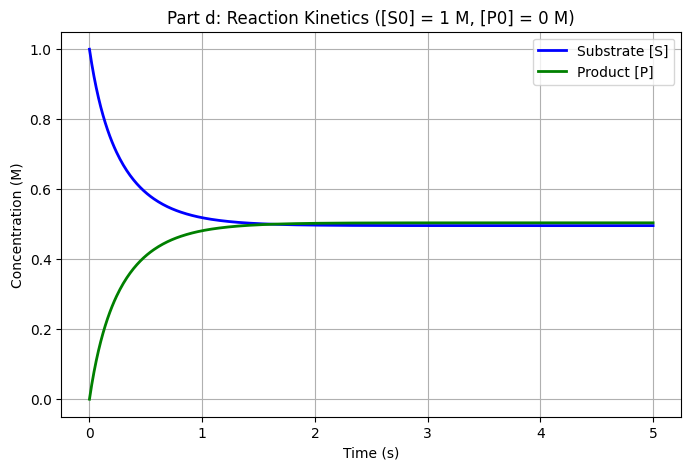

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 1. Define Constants
k1b = 10.0      # s^-1
k2f = 22.0      # s^-1
KmS = 210e-6    # M (converted from microM to M)
KmP = 97e-6     # M (converted from microM to M)
E0 = 0.1        # M

# Calculate missing elementary constants
k1f = (k1b + k2f) / KmS
k2b = (k1b + k2f) / KmP

print(f"Calculated k1f = {k1f:.2f} M^-1 s^-1")
print(f"Calculated k2b = {k2b:.2f} M^-1 s^-1")

# 2. Define the ODE function
def reaction_system(t, y):
    S, P = y
    # Calculate the reaction rate v
    numerator = E0 * (k1f * k2f * S - k1b * k2b * P)
    denominator = k1b + k2f + k1f * S + k2b * P
    v = numerator / denominator
    
    dS_dt = -v
    dP_dt = v
    return [dS_dt, dP_dt]

# 3. Setup Initial Conditions and Time Span
S0_d = 1.0  # M
P0_d = 0.0  # M
y0_d = [S0_d, P0_d]
t_span = (0, 5)
t_eval = np.linspace(0, 5, 500)

# 4. Solve the ODE
sol_d = solve_ivp(reaction_system, t_span, y0_d, t_eval=t_eval, method='Radau')

# 5. Plot the Results
plt.figure(figsize=(8, 5))
plt.plot(sol_d.t, sol_d.y[0], label='Substrate [S]', color='blue', linewidth=2)
plt.plot(sol_d.t, sol_d.y[1], label='Product [P]', color='green', linewidth=2)
plt.title("Part d: Reaction Kinetics ([S0] = 1 M, [P0] = 0 M)")
plt.xlabel("Time (s)")
plt.ylabel("Concentration (M)")
plt.grid(True)
plt.legend()
plt.show()

Starting with no product, the substrate concentration smoothly decreases while the product concentration increases symmetrically. The reaction quickly reaches an equilibrium state where the net rate of reaction approaches zero, leaving a mixture of both substrate and product.

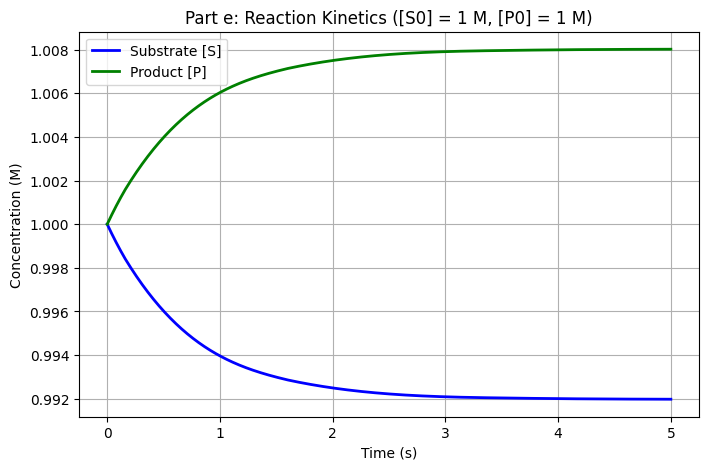

In [3]:
# --- Part e: Solving with [P0] = 1 M ---

# Setup Initial Conditions
S0_e = 1.0  # M
P0_e = 1.0  # M
y0_e = [S0_e, P0_e]

# Solve the ODE
sol_e = solve_ivp(reaction_system, t_span, y0_e, t_eval=t_eval, method='Radau')

# Plot the Results
plt.figure(figsize=(8, 5))
plt.plot(sol_e.t, sol_e.y[0], label='Substrate [S]', color='blue', linewidth=2)
plt.plot(sol_e.t, sol_e.y[1], label='Product [P]', color='green', linewidth=2)
plt.title("Part e: Reaction Kinetics ([S0] = 1 M, [P0] = 1 M)")
plt.xlabel("Time (s)")
plt.ylabel("Concentration (M)")
plt.grid(True)
plt.legend()
plt.show()

### Comments and Comparison to Project 1

**1. Comment on the plot:**
Because we start with a significant amount of product ($1$ mol/L), the system is already much closer to its equilibrium state compared to Part d. The initial reaction rate (the slope of the curves at $t=0$) is much flatter, and the concentrations shift only slightly before flattening out completely as the system reaches equilibrium.

**2. Difference in the rate equation compared to Project 1 Exercise 1:**
In our first project, the reaction was modeled as **irreversible**: $E + S \rightleftharpoons ES \xrightarrow{k_{cat}} E + P$. 
Its QSSA rate equation was:
$$v = \frac{k_{cat}[E_0][S]}{[S] + K_M}$$

In this exercise, the reaction is **fully reversible**, resulting in a more complex rate equation:
$$v = \frac{[E_0](k_{1,f} k_{2,f}[S] - k_{1,b} k_{2,b}[P])}{k_{1,b} + k_{2,f} + k_{1,f}[S] + k_{2,b}[P]}$$

The key differences in our current equation are the subtractive term in the numerator (accounting for the reverse reaction $P \rightarrow S$) and the additive term $+ k_{2,b}[P]$ in the denominator.

**3. Effect of the product concentration on the rate equation:**
An increase in product concentration $[P]$ decreases the net forward reaction rate $v$ in two ways:
* **Thermodynamic Reversibility (Numerator):** It drives the reverse reaction, shrinking the numerator.
* **Competitive Inhibition (Denominator):** The product $P$ competes with the substrate $S$ to bind to the free enzyme $E$. This is represented by the $k_{2,b}[P]$ term in the denominator. A larger denominator means a slower overall rate.

**4. Parameter to change to match Project 1:**
To make this reversible mechanism identical to the irreversible one from Project 1, we must prevent the product from binding to the free enzyme and reversing the reaction. 

Therefore, we must set the reverse binding constant to zero: **$k_{2,b} = 0$**. 

If we do this, the $k_{1,b} k_{2,b}[P]$ term drops from the numerator, and the $k_{2,b}[P]$ term drops from the denominator, leaving:
$$v = \frac{k_{1,f} k_{2,f} [E_0] [S]}{k_{1,b} + k_{2,f} + k_{1,f}[S]}$$
Dividing the top and bottom by $k_{1,f}$, we get exactly the Project 1 equation form, where $k_{2,f}$ acts as $k_{cat}$, and $\frac{k_{1,b} + k_{2,f}}{k_{1,f}}$ acts as $K_M$.